# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

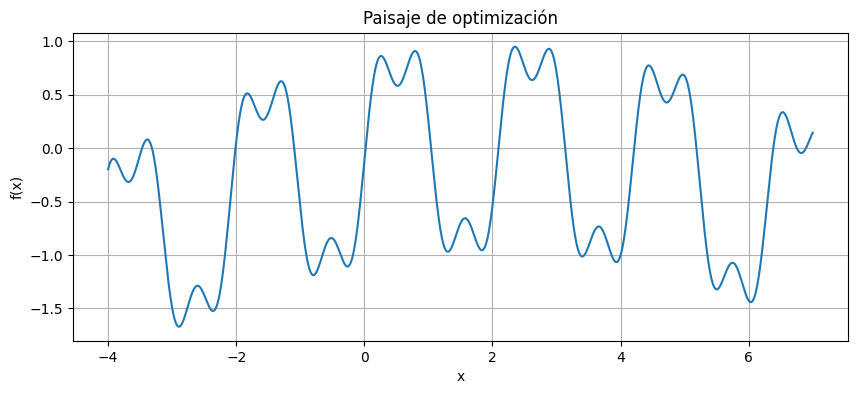

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [2]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [3]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


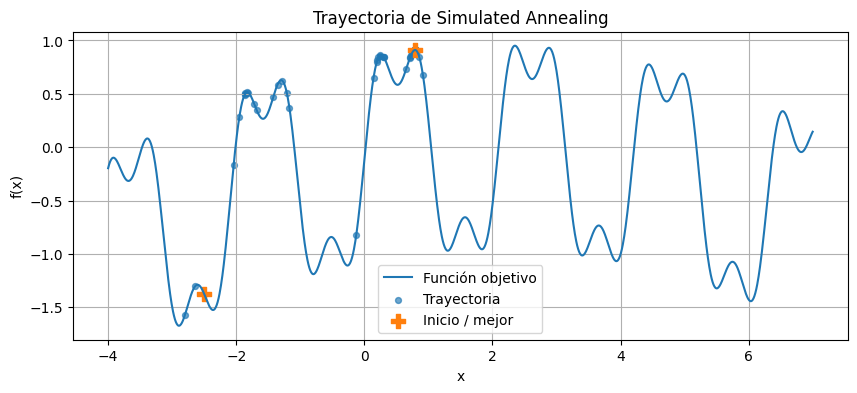

In [4]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

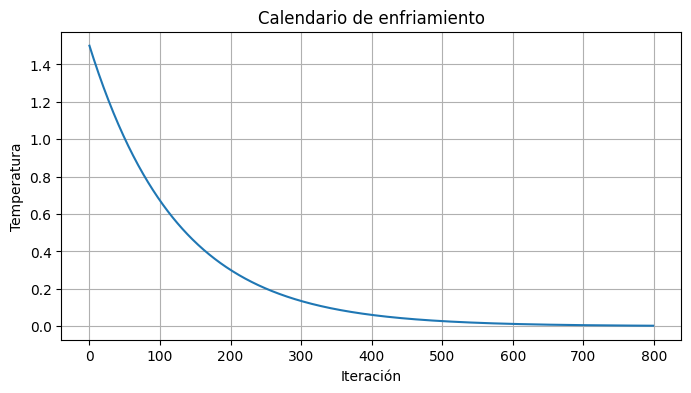

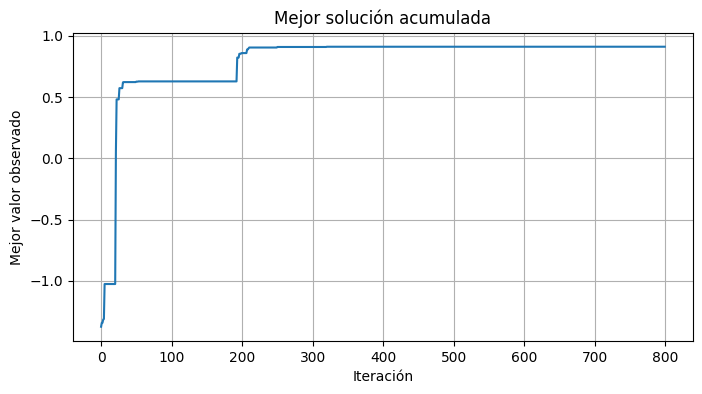

In [5]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


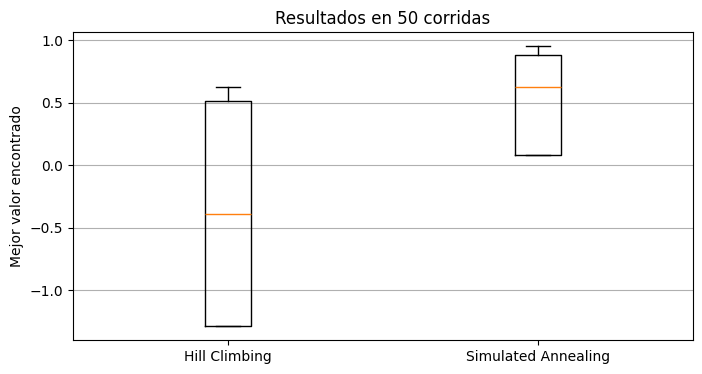

In [6]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [7]:
# Actividad 1 — efecto de la temperatura inicial
# 30 corridas independientes (semillas 0..29) por cada T0, todas desde el mismo x0.

GLOBAL_BEST = float(np.max(ys))   # mejor valor sobre la malla fina: referencia del óptimo global
TOLERANCE = 0.05                  # "cercano al óptimo" si f >= GLOBAL_BEST - TOLERANCE
RUNS = 30

temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]
experiment = []

for temperature in temperatures_to_test:
    values = []
    for seed in range(RUNS):
        _, value, _ = simulated_annealing(x0, initial_temperature=temperature, seed=seed)
        values.append(value)

    values = np.array(values)
    experiment.append({
        'T0': temperature,
        'media': float(values.mean()),
        'desviacion': float(values.std(ddof=1)),
        'pct_cerca_optimo': float(100 * np.mean(values >= GLOBAL_BEST - TOLERANCE)),
        'peor': float(values.min()),
        'mejor': float(values.max()),
        'valores': values
    })

print(f'Óptimo global aproximado (malla): f = {GLOBAL_BEST:.4f}')
print(f'Criterio de éxito: f >= {GLOBAL_BEST - TOLERANCE:.4f}   ({RUNS} corridas por temperatura)\n')
print(f"{'T0':>6} | {'media':>7} | {'std':>7} | {'% cerca':>8} | {'peor':>7} | {'mejor':>7}")
print('-' * 58)
for row in experiment:
    print(f"{row['T0']:>6} | {row['media']:>7.4f} | {row['desviacion']:>7.4f} | "
          f"{row['pct_cerca_optimo']:>7.1f}% | {row['peor']:>7.4f} | {row['mejor']:>7.4f}")

Óptimo global aproximado (malla): f = 0.9509
Criterio de éxito: f >= 0.9009   (30 corridas por temperatura)

    T0 |   media |     std |  % cerca |    peor |   mejor
----------------------------------------------------------
  0.01 |  0.5369 |  0.2069 |     0.0% |  0.0821 |  0.6278
   0.1 |  0.5187 |  0.2220 |     0.0% |  0.0818 |  0.6278
   0.5 |  0.4190 |  0.2844 |     3.3% |  0.0821 |  0.9109
     1 |  0.4830 |  0.3032 |    10.0% |  0.0821 |  0.9510
     3 |  0.6394 |  0.3414 |    46.7% |  0.0821 |  0.9511
    10 |  0.7497 |  0.2371 |    53.3% |  0.0821 |  0.9511


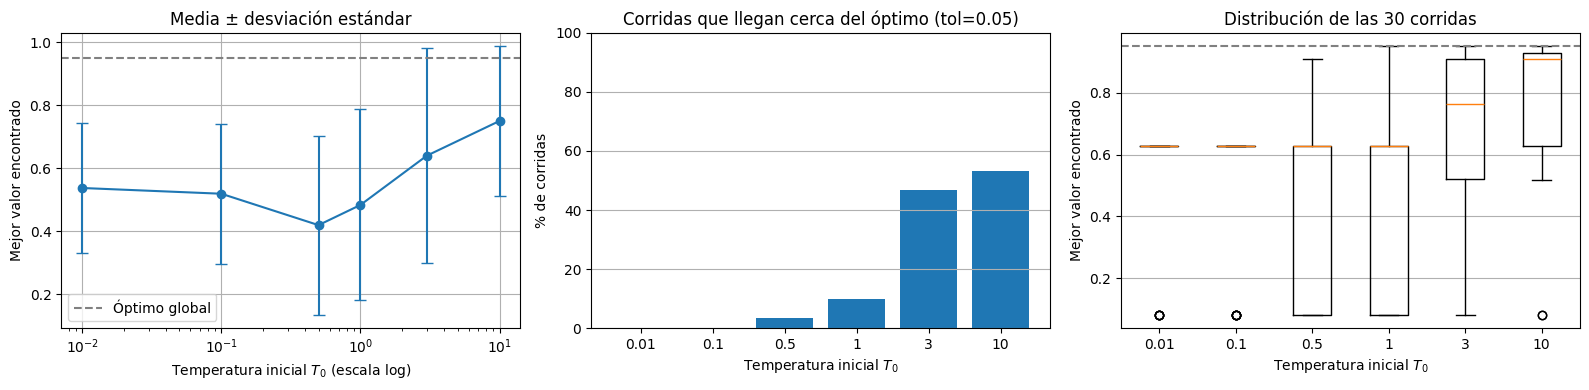

In [8]:
t0_values = [row['T0'] for row in experiment]
means = [row['media'] for row in experiment]
stds = [row['desviacion'] for row in experiment]
success = [row['pct_cerca_optimo'] for row in experiment]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].errorbar(t0_values, means, yerr=stds, marker='o', capsize=4)
axes[0].axhline(GLOBAL_BEST, linestyle='--', color='gray', label='Óptimo global')
axes[0].set_xscale('log')
axes[0].set_xlabel('Temperatura inicial $T_0$ (escala log)')
axes[0].set_ylabel('Mejor valor encontrado')
axes[0].set_title('Media ± desviación estándar')
axes[0].legend()
axes[0].grid(True)

axes[1].bar([str(t) for t in t0_values], success)
axes[1].set_xlabel('Temperatura inicial $T_0$')
axes[1].set_ylabel('% de corridas')
axes[1].set_title(f'Corridas que llegan cerca del óptimo (tol={TOLERANCE})')
axes[1].set_ylim(0, 100)
axes[1].grid(True, axis='y')

axes[2].boxplot([row['valores'] for row in experiment],
                tick_labels=[str(t) for t in t0_values])
axes[2].axhline(GLOBAL_BEST, linestyle='--', color='gray')
axes[2].set_xlabel('Temperatura inicial $T_0$')
axes[2].set_ylabel('Mejor valor encontrado')
axes[2].set_title('Distribución de las 30 corridas')
axes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

#### Análisis — Actividad 1

Con el calendario por defecto ($\alpha=0.992$, 800 iteraciones, `step_size=0.45`) y `x0 = -2.5`:

| $T_0$ | media | std | % cerca del óptimo | peor | mejor |
|------:|------:|----:|-------------------:|-----:|------:|
| 0.01 | 0.537 | 0.207 | 0.0 % | 0.082 | 0.628 |
| 0.1 | 0.519 | 0.222 | 0.0 % | 0.082 | 0.628 |
| 0.5 | 0.419 | 0.284 | 3.3 % | 0.082 | 0.911 |
| 1 | 0.483 | 0.303 | 10.0 % | 0.082 | 0.951 |
| 3 | 0.639 | 0.341 | 46.7 % | 0.082 | 0.951 |
| 10 | 0.750 | 0.237 | 53.3 % | 0.082 | 0.951 |

Para leer la tabla conviene tener presente la estructura del paisaje. Partiendo de $x_0=-2.5$ y avanzando hacia la derecha hay una cadena de máximos locales que sube suavemente ($0.082$ en $x\approx-3.39$, $0.514$ en $x\approx-1.83$, $0.628$ en $x\approx-1.30$) y luego **un valle profundo en $x\approx-0.52$, donde $f=-0.84$**. Solo después de ese valle aparecen los picos altos: $0.864$, $0.911$ y el global $0.951$ en $x\approx 2.35$. Cruzar ese valle es justamente lo que Hill Climbing no puede hacer.

Lecturas principales:

1. **La probabilidad de alcanzar el óptimo global crece de forma monótona con $T_0$**: pasa de 0 % con $T_0\leq 0.1$ a 53 % con $T_0=10$. Es la métrica que realmente importa, y es la que separa a Simulated Annealing de Hill Climbing.
2. **Con $T_0$ muy baja ($0.01$, $0.1$) el algoritmo se comporta como Hill Climbing**: $\exp(\Delta/T)\approx 0$ para cualquier empeoramiento apreciable, así que trepa por la cadena de máximos locales pero se queda del lado izquierdo del valle. Su mejor resultado en 30 corridas es exactamente $0.628$, el techo alcanzable sin cruzarlo. Nunca ve el $0.951$ global.
3. **La media no es monótona** ($T_0=0.5$ tiene media *menor* que $T_0=0.01$). Con temperatura intermedia el algoritmo ya acepta empeorar, así que abandona la cadena segura de máximos locales, pero todavía no tiene suficiente energía para cruzar el valle con fiabilidad: queda deambulando en la región mala. Es la peor combinación: pierde la consistencia de Hill Climbing sin ganar todavía la exploración de SA.
4. **La desviación estándar crece hasta $T_0=3$ y luego baja.** A temperaturas bajas todas las corridas terminan igual (mal, pero consistente); a temperaturas intermedias el resultado es una lotería; a $T_0=10$ la mayoría llega a la zona buena y la dispersión vuelve a caer. Ojo con esto: **una media alta con desviación alta no es lo mismo que un algoritmo confiable**.
5. **El peor caso es $0.082$ en todas las configuraciones**, es decir, el máximo local de $x\approx-3.39$: corridas que se fueron hacia la izquierda y se congelaron allí. Ni siquiera $T_0=10$ lo evita: con 800 iteraciones y $\alpha=0.992$ la temperatura ya cae por debajo de $0.5$ hacia la iteración ~370, y si para entonces la corrida no cruzó el valle, se congela donde esté. La temperatura inicial por sí sola no basta; hay que mirarla junto con el calendario de enfriamiento (Actividad 2).

### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

In [9]:
# Actividad 2 — efecto de la tasa de enfriamiento alpha (T0 fija en 1.5, 800 iteraciones)

cooling_rates_to_test = [0.85, 0.90, 0.95, 0.99, 0.992, 0.999, 1.0]
T0_FIXED = 1.5
ITERATIONS = 800

cooling_experiment = []

for alpha in cooling_rates_to_test:
    values = []
    worse_accepted = []
    for seed in range(RUNS):
        _, value, records = simulated_annealing(
            x0,
            iterations=ITERATIONS,
            initial_temperature=T0_FIXED,
            cooling_rate=alpha,
            seed=seed
        )
        values.append(value)
        # proporción de iteraciones en las que se aceptó un candidato peor o igual
        worse_accepted.append(np.mean([r['accepted'] and r['delta'] <= 0 for r in records]))

    values = np.array(values)

    # iteración en la que la temperatura cae por debajo de 0.01 ("congelamiento" práctico)
    if alpha < 1.0:
        frozen_at = math.ceil(math.log(0.01 / T0_FIXED) / math.log(alpha))
    else:
        frozen_at = float('inf')

    cooling_experiment.append({
        'alpha': alpha,
        'media': float(values.mean()),
        'desviacion': float(values.std(ddof=1)),
        'pct_cerca_optimo': float(100 * np.mean(values >= GLOBAL_BEST - TOLERANCE)),
        'pct_movimientos_peores': float(100 * np.mean(worse_accepted)),
        'congela_en': frozen_at,
        'valores': values
    })

print(f"{'alpha':>6} | {'media':>7} | {'std':>7} | {'% cerca':>8} | "
      f"{'% acepta peores':>15} | {'T<0.01 en iter.':>16}")
print('-' * 78)
for row in cooling_experiment:
    frozen = 'nunca' if row['congela_en'] == float('inf') else f"{row['congela_en']}"
    print(f"{row['alpha']:>6} | {row['media']:>7.4f} | {row['desviacion']:>7.4f} | "
          f"{row['pct_cerca_optimo']:>7.1f}% | {row['pct_movimientos_peores']:>14.1f}% | {frozen:>16}")

 alpha |   media |     std |  % cerca | % acepta peores |  T<0.01 en iter.
------------------------------------------------------------------------------
  0.85 |  0.3913 |  0.2751 |     0.0% |            0.9% |               31
   0.9 |  0.3810 |  0.2875 |     0.0% |            1.4% |               48
  0.95 |  0.3826 |  0.2904 |     3.3% |            3.1% |               98
  0.99 |  0.4869 |  0.3338 |    20.0% |           14.7% |              499
 0.992 |  0.5557 |  0.3420 |    33.3% |           18.2% |              624
 0.999 |  0.8511 |  0.1863 |    73.3% |           42.2% |             5009
   1.0 |  0.9042 |  0.0971 |    83.3% |           44.7% |            nunca


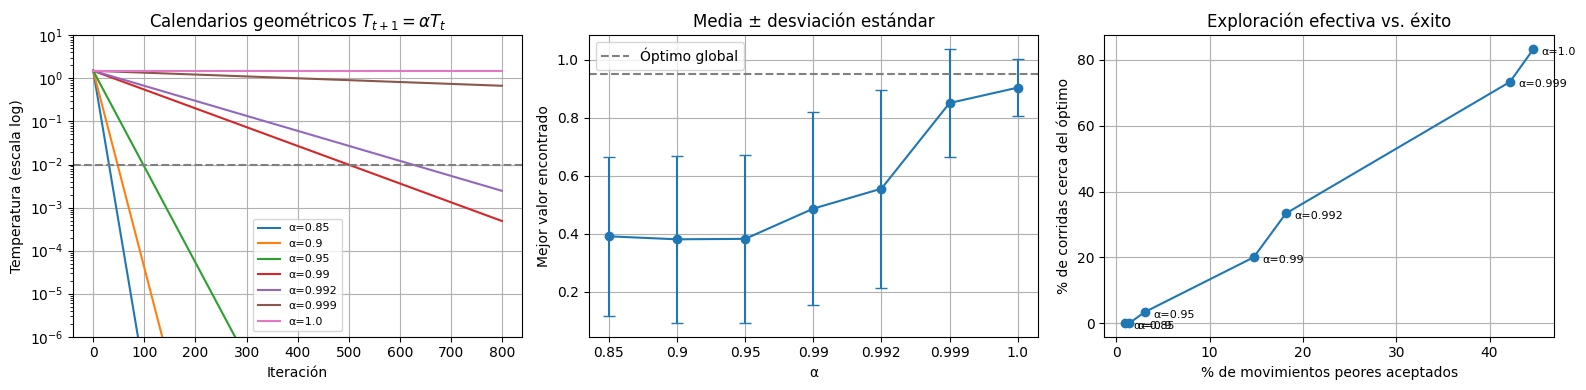

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1) calendarios de enfriamiento
for alpha in cooling_rates_to_test:
    temps = [T0_FIXED * (alpha ** t) for t in range(ITERATIONS)]
    axes[0].plot(range(ITERATIONS), temps, label=f'α={alpha}')
axes[0].axhline(0.01, linestyle='--', color='gray')
axes[0].set_yscale('log')
axes[0].set_ylim(1e-6, 10)
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Temperatura (escala log)')
axes[0].set_title('Calendarios geométricos $T_{t+1}=\\alpha T_t$')
axes[0].legend(fontsize=8)
axes[0].grid(True)

# 2) calidad promedio
alphas = [row['alpha'] for row in cooling_experiment]
axes[1].errorbar([str(a) for a in alphas],
                 [row['media'] for row in cooling_experiment],
                 yerr=[row['desviacion'] for row in cooling_experiment],
                 marker='o', capsize=4)
axes[1].axhline(GLOBAL_BEST, linestyle='--', color='gray', label='Óptimo global')
axes[1].set_xlabel('α')
axes[1].set_ylabel('Mejor valor encontrado')
axes[1].set_title('Media ± desviación estándar')
axes[1].legend()
axes[1].grid(True)

# 3) exploración efectiva vs. éxito
axes[2].plot([row['pct_movimientos_peores'] for row in cooling_experiment],
             [row['pct_cerca_optimo'] for row in cooling_experiment],
             marker='o')
for row in cooling_experiment:
    axes[2].annotate(f"α={row['alpha']}",
                     (row['pct_movimientos_peores'], row['pct_cerca_optimo']),
                     textcoords='offset points', xytext=(6, -4), fontsize=8)
axes[2].set_xlabel('% de movimientos peores aceptados')
axes[2].set_ylabel('% de corridas cerca del óptimo')
axes[2].set_title('Exploración efectiva vs. éxito')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Hill Climbing estocástico   — media -0.1991 | máx 0.6278 | % cerca 0.0%
SA con α=0.85 (rápido)      — media 0.3913 | máx 0.6278 | % cerca 0.0%
SA con α=0.999 (lento)      — media 0.8511 | máx 0.9511 | % cerca 73.3%

Sin enfriamiento (α=1.0): mejor histórico 0.9487, valor actual al terminar -0.1938


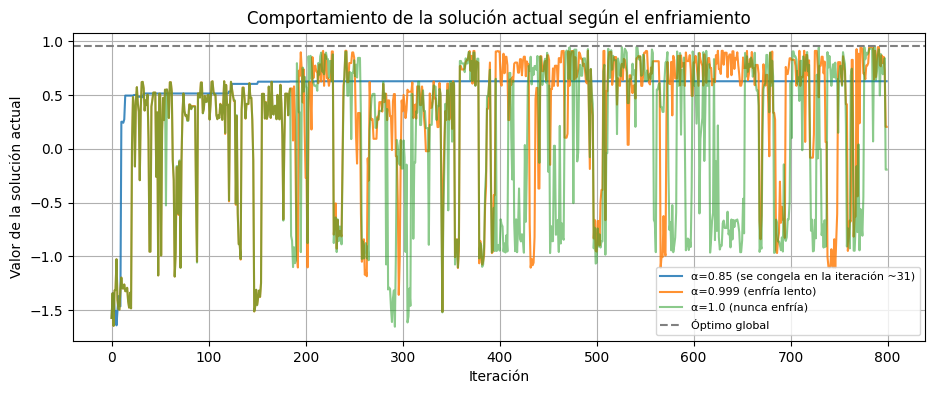

In [11]:
# ¿Enfriar rápido = Hill Climbing? Comparación directa con la línea base del punto 2.

hill_baseline = np.array([float(objective(stochastic_hill_climbing(x0, seed=seed)[0]))
                          for seed in range(RUNS)])
sa_fast = np.array([simulated_annealing(x0, cooling_rate=0.85, seed=seed)[1]
                    for seed in range(RUNS)])
sa_slow = np.array([simulated_annealing(x0, cooling_rate=0.999, seed=seed)[1]
                    for seed in range(RUNS)])

print(f'Hill Climbing estocástico   — media {hill_baseline.mean():.4f} | '
      f'máx {hill_baseline.max():.4f} | % cerca {100 * np.mean(hill_baseline >= GLOBAL_BEST - TOLERANCE):.1f}%')
print(f'SA con α=0.85 (rápido)      — media {sa_fast.mean():.4f} | '
      f'máx {sa_fast.max():.4f} | % cerca {100 * np.mean(sa_fast >= GLOBAL_BEST - TOLERANCE):.1f}%')
print(f'SA con α=0.999 (lento)      — media {sa_slow.mean():.4f} | '
      f'máx {sa_slow.max():.4f} | % cerca {100 * np.mean(sa_slow >= GLOBAL_BEST - TOLERANCE):.1f}%')

# α=1.0 nunca enfría: la solución actual no converge, solo sobrevive la memoria del mejor
_, best_no_cooling, records_no_cooling = simulated_annealing(x0, cooling_rate=1.0, seed=SEED)
final_current = records_no_cooling[-1]['value']
print(f'\nSin enfriamiento (α=1.0): mejor histórico {best_no_cooling:.4f}, '
      f'valor actual al terminar {final_current:.4f}')

_, _, records_slow = simulated_annealing(x0, cooling_rate=0.999, seed=SEED)
_, _, records_fast = simulated_annealing(x0, cooling_rate=0.85, seed=SEED)

plt.figure(figsize=(11, 4))
plt.plot([r['value'] for r in records_fast], label='α=0.85 (se congela en la iteración ~31)', alpha=0.85)
plt.plot([r['value'] for r in records_slow], label='α=0.999 (enfría lento)', alpha=0.85)
plt.plot([r['value'] for r in records_no_cooling], label='α=1.0 (nunca enfría)', alpha=0.55)
plt.axhline(GLOBAL_BEST, linestyle='--', color='gray', label='Óptimo global')
plt.xlabel('Iteración')
plt.ylabel('Valor de la solución actual')
plt.title('Comportamiento de la solución actual según el enfriamiento')
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

#### Análisis — Actividad 2

Con $T_0=1.5$ fija y 800 iteraciones:

| $\alpha$ | media | std | % cerca del óptimo | % movimientos peores aceptados | $T<0.01$ en la iteración |
|-------:|------:|----:|-------------------:|-------------------------------:|-------------------------:|
| 0.85 | 0.391 | 0.275 | 0.0 % | 0.9 % | 31 |
| 0.90 | 0.381 | 0.288 | 0.0 % | 1.4 % | 48 |
| 0.95 | 0.383 | 0.290 | 3.3 % | 3.1 % | 98 |
| 0.99 | 0.487 | 0.334 | 20.0 % | 14.7 % | 499 |
| 0.992 | 0.556 | 0.342 | 33.3 % | 18.2 % | 624 |
| 0.999 | 0.851 | 0.186 | 73.3 % | 42.2 % | 5009 |
| 1.0 | 0.904 | 0.097 | 83.3 % | 44.7 % | nunca |

**¿Por qué un enfriamiento demasiado rápido convierte el algoritmo en Hill Climbing?**

El calendario geométrico $T_t = T_0\,\alpha^t$ decae exponencialmente, y la temperatura entra en la probabilidad de aceptación dentro de otra exponencial, así que el efecto es doblemente exponencial:

$$
P(\text{aceptar} \mid \Delta<0) = \exp\left(\frac{\Delta}{T_0\alpha^{t}}\right)
$$

Con $\alpha=0.85$ y $T_0=1.5$, en la iteración 31 ya se cumple $T<0.01$. A partir de ahí, un empeoramiento típico de $\Delta=-0.1$ tiene probabilidad de aceptación $\exp(-0.1/0.01)=e^{-10}\approx 4.5\times10^{-5}$: en la práctica, cero. Las 769 iteraciones restantes solo aceptan candidatos que mejoran, que es **exactamente la regla de Hill Climbing estocástico** del punto 2.

Los números lo confirman: con $\alpha=0.85$ solo el 0.9 % de las iteraciones aceptó un empeoramiento y, igual que Hill Climbing, **ninguna de las 30 corridas cruzó el valle** (0 % de éxito, y máximo $0.6278$ en ambos casos: el mismo techo del óptimo local). La media de SA con $\alpha=0.85$ ($0.391$) queda por encima de la de Hill Climbing ($-0.199$) solo por dos detalles operativos —conserva el mejor histórico y dispone de más iteraciones con un paso mayor durante la fase caliente—, no porque explore mejor. La limitación estructural es idéntica.

El costo del enfriamiento rápido no es solo teórico: **se desperdicia el presupuesto de iteraciones**. El algoritmo gasta 800 evaluaciones pero solo ~31 son de exploración real; el resto es descenso local en la cuenca donde lo dejó el azar.

**El otro extremo también tiene una trampa.** Con $\alpha=1.0$ la media es la mejor de la tabla ($0.904$), pero eso no significa que el algoritmo "converja mejor": la solución actual nunca se estabiliza, sigue haciendo un paseo aleatorio hasta la última iteración. En la corrida de ejemplo el mejor histórico es $0.9487$ mientras que el valor actual al terminar es $-0.194$, y en la gráfica se ve oscilando de arriba a abajo sin asentarse. Todo el mérito es de la memoria `best_value`, no de la búsqueda. En este problema unidimensional y acotado eso alcanza; en un espacio grande, un paseo aleatorio puro casi nunca visita la región buena y la estrategia colapsa.

**Conclusión práctica:** $\alpha$ debe elegirse junto con el número de iteraciones, de modo que la temperatura llegue a valores despreciables *cerca del final* del presupuesto y no antes. Una regla útil es fijar $T_{\text{final}}$ y despejar

$$
\alpha=\left(\frac{T_{\text{final}}}{T_0}\right)^{1/N}
$$

Para $T_0=1.5$, $T_{\text{final}}=0.01$ y $N=800$ iteraciones, esto da $\alpha\approx 0.9938$, consistente con el $0.992$ que trae el notebook por defecto.

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(\text{actual})-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

Casas: 18 | Hospitales: 3 | Cuadrícula: 10x16
Costo del estado inicial: 87


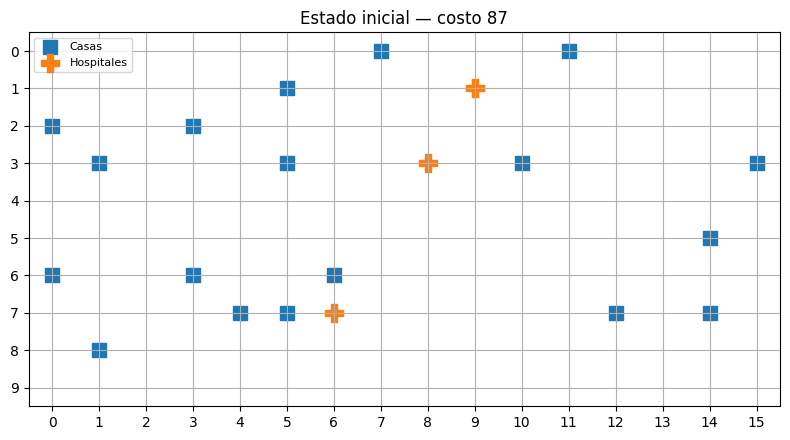

In [12]:
# Actividad 3 — Simulated Annealing en el problema discreto de hospitales (notebook 01)

HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3
GRID_SEED = 8

grid_rng = random.Random(GRID_SEED)
all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(grid_rng.sample(all_cells, NUM_HOUSES))
free_cells = sorted(set(all_cells) - houses)
initial_hospitals = set(grid_rng.sample(free_cells, NUM_HOSPITALS))


def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    """C(H): suma de la distancia de cada casa al hospital más cercano. Se MINIMIZA."""
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def neighbors_of_state(height, width, houses, hospitals):
    """Mismo vecindario del notebook 01: mover un hospital una celda."""
    neighbors = []
    for hospital in hospitals:
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)
    return neighbors


def plot_state(height, width, houses, hospitals, title=None, ax=None):
    created = ax is None
    if created:
        _, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)
    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    if created:
        plt.tight_layout()
        plt.show()


print(f'Casas: {NUM_HOUSES} | Hospitales: {NUM_HOSPITALS} | Cuadrícula: {HEIGHT}x{WIDTH}')
print(f'Costo del estado inicial: {total_cost(houses, initial_hospitals)}')
plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

In [13]:
# Línea base: Hill Climbing del notebook 01 (mejor vecino, se detiene en el óptimo local)

def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = sorted(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break
        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        if best_cost >= history[-1]:
            break
        current = set(rng.choice([n for n, c in zip(neighbors, costs) if c == best_cost]))
        history.append(best_cost)

    return current, history


hc_solution, hc_history = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(GRID_SEED)
)
print(f'Hill Climbing: costo {hc_history[0]} -> {hc_history[-1]} '
      f'en {len(hc_history) - 1} movimientos de mejora')

Hill Climbing: costo 87 -> 62 en 9 movimientos de mejora


In [14]:
# Simulated Annealing adaptado a MINIMIZACIÓN.
#
# Regla de aceptación: con  delta = C(actual) - C(candidato),
#   delta > 0  ->  el candidato es MEJOR (cuesta menos)  ->  se acepta siempre
#   delta <= 0 ->  el candidato es peor o igual          ->  se acepta con prob. exp(delta / T)
# Es la misma lógica del caso de maximización; solo cambia el signo de la diferencia.

def random_neighbor_state(height, width, houses, hospitals, rng):
    """Un vecino al azar: un hospital se mueve una celda a una posición válida."""
    neighbors = neighbors_of_state(height, width, houses, hospitals)
    return rng.choice(neighbors) if neighbors else set(hospitals)


def simulated_annealing_hospitals(height, width, houses, num_hospitals, initial_state=None,
                                  iterations=2000, initial_temperature=8.0,
                                  cooling_rate=0.995, seed=0):
    rng = random.Random(seed)
    available = sorted(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    current_cost = total_cost(houses, current)
    best_state, best_cost = set(current), current_cost
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor_state(height, width, houses, current, rng)
        candidate_cost = total_cost(houses, candidate)
        delta = current_cost - candidate_cost          # > 0 significa mejora al minimizar

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            current, current_cost = candidate, candidate_cost

        if current_cost < best_cost:
            best_state, best_cost = set(current), current_cost

        records.append({
            'iteration': iteration,
            'cost': current_cost,
            'best_cost': best_cost,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_state, best_cost, records


sa_solution, sa_cost, sa_records = simulated_annealing_hospitals(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    seed=GRID_SEED
)
print(f'Simulated Annealing: costo {hc_history[0]} -> {sa_cost}')
print(f'Hill Climbing desde el mismo estado inicial: {hc_history[-1]}')

Simulated Annealing: costo 87 -> 56
Hill Climbing desde el mismo estado inicial: 62


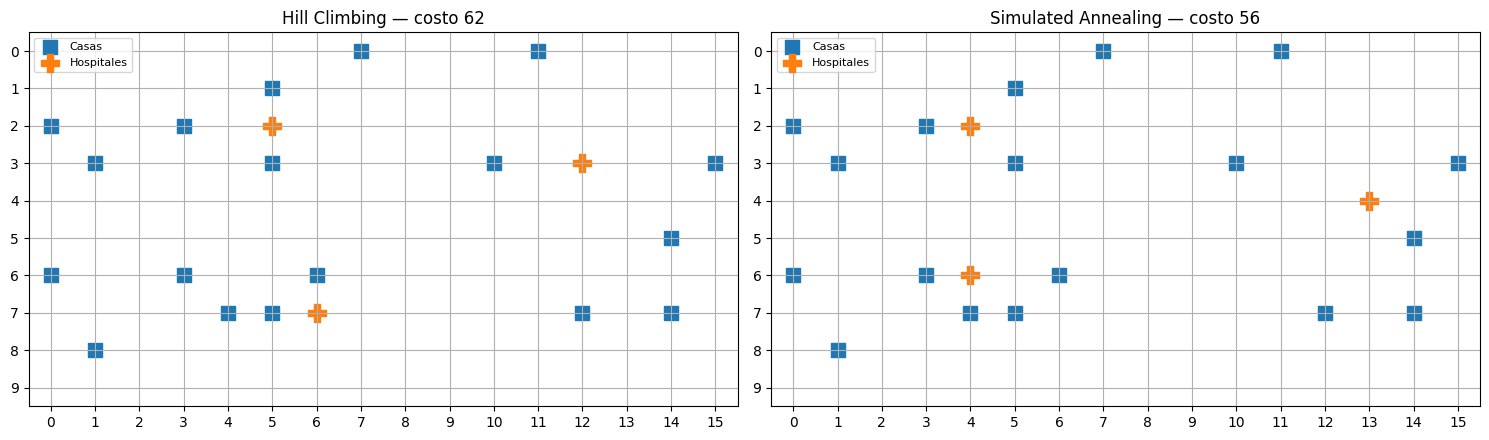

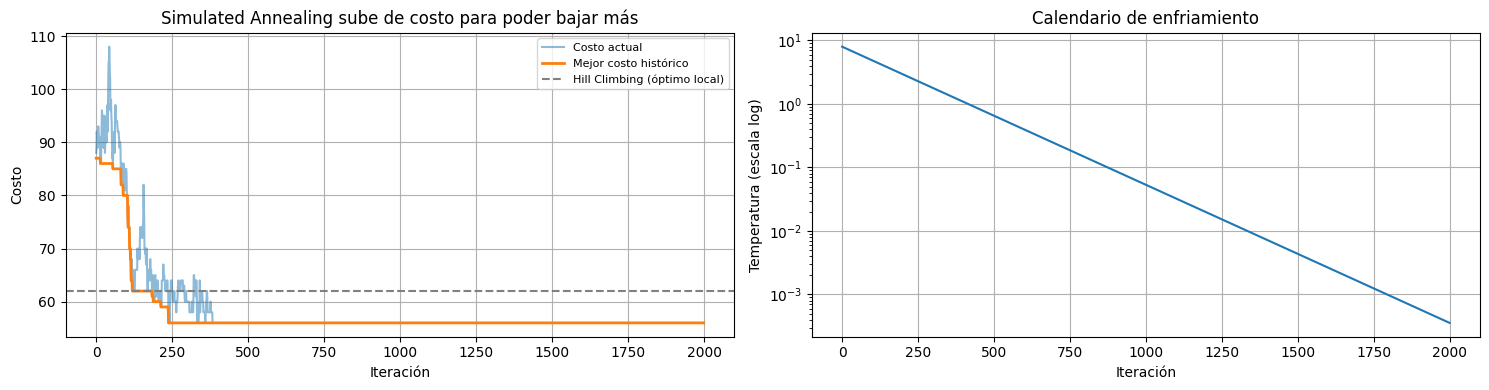

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_state(HEIGHT, WIDTH, houses, hc_solution,
           title=f'Hill Climbing — costo {hc_history[-1]}', ax=axes[0])
plot_state(HEIGHT, WIDTH, houses, sa_solution,
           title=f'Simulated Annealing — costo {sa_cost}', ax=axes[1])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot([r['cost'] for r in sa_records], alpha=0.5, label='Costo actual')
axes[0].plot([r['best_cost'] for r in sa_records], linewidth=2, label='Mejor costo histórico')
axes[0].axhline(hc_history[-1], linestyle='--', color='gray', label='Hill Climbing (óptimo local)')
axes[0].set_xlabel('Iteración')
axes[0].set_ylabel('Costo')
axes[0].set_title('Simulated Annealing sube de costo para poder bajar más')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].plot([r['temperature'] for r in sa_records])
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Temperatura (escala log)')
axes[1].set_title('Calendario de enfriamiento')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Hill Climbing (1 corrida)     — media 70.80 | mejor 57 | peor 132
Simulated Annealing (1 corrida) — media 56.37 | mejor 56 | peor 60
Random Restart (40 reinicios)  — mejor 56


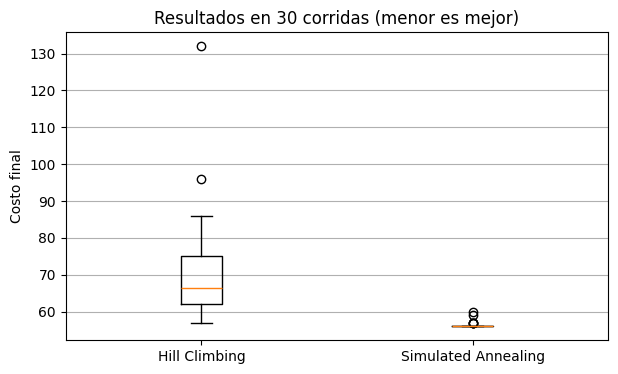

In [16]:
# Comparación estadística: 30 corridas con estado inicial aleatorio para cada algoritmo

DISCRETE_RUNS = 30
hc_costs, sa_costs = [], []

for seed in range(DISCRETE_RUNS):
    _, history = hill_climbing(HEIGHT, WIDTH, houses, NUM_HOSPITALS, rng=random.Random(seed))
    hc_costs.append(history[-1])
    _, cost, _ = simulated_annealing_hospitals(HEIGHT, WIDTH, houses, NUM_HOSPITALS, seed=seed)
    sa_costs.append(cost)

# Random Restart con 40 reinicios, como referencia del notebook 01
master_rng = random.Random(GRID_SEED)
restart_costs = [hill_climbing(HEIGHT, WIDTH, houses, NUM_HOSPITALS,
                               rng=random.Random(master_rng.randrange(10 ** 9)))[1][-1]
                 for _ in range(40)]

print(f'Hill Climbing (1 corrida)     — media {np.mean(hc_costs):.2f} | '
      f'mejor {min(hc_costs)} | peor {max(hc_costs)}')
print(f'Simulated Annealing (1 corrida) — media {np.mean(sa_costs):.2f} | '
      f'mejor {min(sa_costs)} | peor {max(sa_costs)}')
print(f'Random Restart (40 reinicios)  — mejor {min(restart_costs)}')

plt.figure(figsize=(7, 4))
plt.boxplot([hc_costs, sa_costs], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Costo final')
plt.title(f'Resultados en {DISCRETE_RUNS} corridas (menor es mejor)')
plt.grid(True, axis='y')
plt.show()

In [17]:
# ¿Cómo escoger T0 en el caso discreto? Los costos son enteros, así que los
# empeoramientos típicos valen 1, 2 o 3 unidades: T0 debe estar en ese orden de magnitud.

print(f"{'T0':>6} | {'media':>7} | {'mejor':>6} | {'peor':>6} | {'% en el mejor conocido':>23}")
print('-' * 62)
best_known = min(min(sa_costs), min(restart_costs))
for T0 in [0.5, 2, 5, 8, 20, 100]:
    costs = np.array([simulated_annealing_hospitals(HEIGHT, WIDTH, houses, NUM_HOSPITALS,
                                                    initial_temperature=T0, seed=seed)[1]
                      for seed in range(DISCRETE_RUNS)])
    print(f'{T0:>6} | {costs.mean():>7.2f} | {costs.min():>6} | {costs.max():>6} | '
          f'{100 * np.mean(costs == best_known):>22.1f}%')
print(f'\nMejor costo conocido para esta instancia: {best_known}')

    T0 |   media |  mejor |   peor |  % en el mejor conocido
--------------------------------------------------------------


   0.5 |   60.47 |     56 |     72 |                   16.7%


     2 |   57.93 |     56 |     62 |                   50.0%


     5 |   56.17 |     56 |     60 |                   93.3%


     8 |   56.37 |     56 |     60 |                   80.0%


    20 |   56.17 |     56 |     58 |                   90.0%


   100 |   56.47 |     56 |     61 |                   80.0%

Mejor costo conocido para esta instancia: 56


#### Análisis — Actividad 3

**Qué hubo que cambiar para pasar de maximizar a minimizar:**

| Elemento | Notebook (maximización) | Hospitales (minimización) |
|---|---|---|
| Objetivo | $f(x)$, se busca el máximo | $C(H)$, se busca el mínimo |
| Diferencia | $\Delta = f(x')-f(x)$ | $\Delta = C(\text{actual})-C(\text{candidato})$ |
| Aceptación | $\Delta>0$ siempre; si no, $\exp(\Delta/T)$ | idéntica |
| Memoria del mejor | `if current_value > best_value` | `if current_cost < best_cost` |
| Vecino | perturbación continua $x\pm U(0,s)$ | mover **un** hospital **una** celda a una posición válida |

Al definir $\Delta$ como *actual menos candidato*, un $\Delta$ positivo vuelve a significar "el candidato es mejor", así que **la regla de aceptación y toda la maquinaria del notebook se reutilizan sin tocar una línea**. Ese es el truco general: SA no necesita saber si el problema es de máximo o de mínimo, solo necesita un $\Delta$ orientado a "mejora".

**Diferencia importante en la generación de vecinos.** El Hill Climbing del notebook 01 evalúa *todos* los vecinos y toma el mejor (~12 evaluaciones de costo por paso). Simulated Annealing toma **un vecino al azar** y decide si lo acepta: 1 evaluación por iteración. Por eso puede permitirse 2000 iteraciones con un costo computacional comparable al de unas 170 iteraciones de Hill Climbing.

**Resultados (30 corridas, estado inicial aleatorio):**

| Algoritmo | media | mejor | peor |
|---|---:|---:|---:|
| Hill Climbing (una corrida) | 70.8 | 57 | 132 |
| Simulated Annealing (una corrida) | 56.4 | **56** | 60 |
| Random Restart, 40 reinicios | — | 56 | — |

1. **SA gana con claridad**: su media ($56.4$) es mejor que el *mejor* resultado de Hill Climbing en 30 intentos ($57$), y su peor caso ($60$) queda muy lejos del peor de Hill Climbing ($132$), un óptimo local pésimo.
2. **Una sola corrida de SA iguala lo que Random Restart consigue con 40 reinicios** (costo $56$). SA no necesita reiniciar: la temperatura le permite salir de los óptimos locales sin tirar a la basura el progreso acumulado, mientras que cada reinicio de Random Restart empieza de cero.
3. **La varianza cae drásticamente.** Hill Climbing depende por completo del estado inicial; SA es mucho más robusto a esa lotería.
4. **La escala de $T_0$ importa y depende del problema.** Aquí los costos son enteros y los empeoramientos típicos valen 1 a 3 unidades, así que $T_0$ debe estar en ese orden de magnitud: con $T_0=0.5$ la exponencial ya castiga demasiado ($e^{-2}=0.14$ para $\Delta=-1$) y solo el 16.7 % de las corridas llega al mejor costo conocido; a partir de $T_0\approx 5$ el desempeño se estabiliza en torno al 80–93 %, y subir hasta $T_0=100$ no aporta nada (solo gasta iteraciones aceptando basura al principio). **La temperatura no es adimensional: se compara contra la magnitud de los $\Delta$ de la función objetivo.** Un $T_0$ que funciona en un problema no se traslada a otro sin reescalarlo.

## Preguntas de cierre

1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?
2. ¿Qué ocurre si la temperatura nunca disminuye?
3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?
4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

### 1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?

Porque **la solución actual no es monótona**: por diseño el algoritmo acepta empeoramientos, así que puede terminar en un punto peor que otro que ya visitó. Sin memoria, todo el trabajo de haber pasado por una buena región se perdería.

Se ve en los experimentos:

- Con $\alpha=1.0$ (sin enfriamiento) el mejor histórico de la corrida de ejemplo fue $0.9487$, pero el valor actual al terminar era $-0.194$. Sin `best_value`, esa corrida se habría reportado como un fracaso rotundo.
- Incluso con enfriamiento normal, la última iteración puede caer justo después de haber aceptado un movimiento malo.

Guardar el mejor cuesta $O(1)$ en memoria y convierte a SA en un algoritmo **anytime**: se puede detener en cualquier momento y siempre hay una respuesta válida, la mejor vista hasta ahí. Formalmente, separa dos roles que en Hill Climbing coinciden por accidente: la solución actual es el *estado de la búsqueda* (necesita libertad para deambular) y el mejor histórico es el *resultado* (necesita ser monótono).

### 2. ¿Qué ocurre si la temperatura nunca disminuye?

El algoritmo se convierte en un **paseo aleatorio sesgado** que nunca converge. Con $T$ constante y alta, $\exp(\Delta/T)\approx 1$ para casi cualquier $\Delta$, así que se acepta prácticamente todo y la solución actual oscila indefinidamente: en el experimento con $\alpha=1.0$ el 44.7 % de las iteraciones aceptaron movimientos peores, frente al 18.2 % de $\alpha=0.992$.

Con $T$ fija la búsqueda no converge a un punto sino a una **distribución estacionaria de Boltzmann**, $P(x)\propto e^{f(x)/T}$: pasa más tiempo en zonas buenas, pero no se estabiliza en ninguna. Se pierde la fase de refinamiento.

Un detalle contraintuitivo del experimento: $\alpha=1.0$ dio la **mejor** media ($0.904$) y el mayor porcentaje de éxito (83 %). Eso no valida "no enfriar". Ocurre porque (a) el dominio es unidimensional y acotado, así que un paseo aleatorio de 800 pasos recorre todo el espacio, y (b) el mérito es enteramente de la memoria `best_value`, no de la búsqueda. En un espacio grande o de alta dimensión un paseo aleatorio casi nunca visita la región óptima y la estrategia colapsa. Enfriar es lo que le da a SA su carácter de **búsqueda** en lugar de muestreo: primero explora, después refina.

### 3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?

**Simulated Annealing degenera en Hill Climbing estocástico.** Cuando $T\to 0^+$, para cualquier $\Delta<0$ se tiene $\exp(\Delta/T)\to 0$, así que solo se aceptan candidatos que mejoran, que es la regla del punto 2 de este notebook.

Los datos lo confirman: con $T_0=0.01$ y $T_0=0.1$, **ninguna** de las 30 corridas llegó cerca del óptimo global, y el máximo alcanzado fue $0.6278$ en ambos casos, es decir, el máximo local de $x\approx-1.30$: el mejor punto accesible desde $x_0=-2.5$ sin atravesar el valle profundo de $x\approx-0.52$ ($f=-0.84$). El algoritmo nunca vio el $0.951$ global porque para llegar allí hay que empeorar temporalmente.

La contrapartida es que la desviación estándar es la más baja de la tabla ($0.207$): con temperatura casi nula el resultado es consistente, pero consistentemente subóptimo. Es el mismo fenómeno que el enfriamiento demasiado rápido de la Actividad 2, solo que causado por $T_0$ en lugar de por $\alpha$.

### 4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?

**No.** Con recursos finitos, SA es un algoritmo estocástico sin garantía: entrega una buena solución con alta probabilidad, no una solución óptima con certeza.

La evidencia está en los propios experimentos: incluso con $T_0=10$, la mejor configuración de la Actividad 1, solo el 53 % de las corridas llegó cerca del óptimo global, y **alguna semilla terminó en $0.082$** —el máximo local de $x\approx-3.39$— porque se congeló antes de cruzar el valle. Aumentar $T_0$ o subir $\alpha$ mejora la probabilidad (73 % con $\alpha=0.999$), pero nunca la lleva a 1 con un presupuesto acotado.

Sí existe un resultado teórico de convergencia (Geman y Geman, 1984): si el calendario es **logarítmico**,

$$
T_t \geq \frac{c}{\log(1+t)}
$$

con $c$ suficientemente grande, entonces la probabilidad de estar en el óptimo global tiende a 1 cuando $t\to\infty$. El problema es que ese calendario es inútil en la práctica: enfría tan despacio que alcanzar el óptimo puede requerir más iteraciones que enumerar el espacio de búsqueda completo. Por eso en la práctica se usan calendarios geométricos $T_{t+1}=\alpha T_t$, mucho más rápidos pero que **pierden la garantía**.

En resumen: SA cambia la garantía de optimalidad por eficiencia. Es el mismo trato que hace Random Restart en el notebook 01 y, en general, toda la familia de metaheurísticas. Si se necesita una garantía real de optimalidad hay que ir a métodos exactos (programación entera, ramificación y acotamiento, búsqueda exhaustiva), pagando un costo computacional muy superior.

---

### Resumen del notebook

| Parámetro | Si es muy bajo | Si es muy alto | Cómo elegirlo |
|---|---|---|---|
| $T_0$ | degenera en Hill Climbing y se atasca en el óptimo local de turno | desperdicia iteraciones en un paseo aleatorio | del orden de magnitud de los $\Delta$ típicos de la función objetivo |
| $\alpha$ | se congela pronto y desperdicia el presupuesto de iteraciones | nunca refina, la solución actual no converge | $\alpha=(T_{\text{final}}/T_0)^{1/N}$, con $N$ = iteraciones disponibles |
| `step_size` | vecinos casi idénticos, avanza muy lento | vecinos sin relación con el actual, se pierde la estructura local | que permita salir de una cuenca en unos pocos pasos |

**La idea central:** Hill Climbing solo baja por la pendiente y queda preso del primer óptimo local; Simulated Annealing paga una probabilidad decreciente de empeorar a cambio de poder cruzar valles, y usa la memoria del mejor histórico para que ese riesgo nunca se traduzca en un peor resultado final.